![header](header.png)

# Procesamiento Digital de Señales en Sistemas Embebidos

---

# Actividad: Análisis Frecuencial

## Introducción
El análisis de señales en el dominio de la frecuencia permite estudiar cómo se distribuye la energía de una señal a lo largo del espectro de frecuencias. En muchos casos, la información relevante que no es visible en el dominio temporal se vuelve evidente al analizar la señal en el dominio frecuencial.

La herramienta fundamental para este tipo de análisis es la Transformada de Fourier (`FT`), que permite descomponer una señal en sus componentes sinusoidales. En el caso de señales discretas (digitales), se utiliza la Transformada Discreta de Fourier (`DFT`). Para implementarla de manera eficiente en sistemas de cómputo, se recurre a la Transformada Rápida de Fourier (`FFT`), un algoritmo que reduce significativamente el número de operaciones necesarias para calcular la `DFT`.

El espectro de magnitud obtenido a partir de la FFT puede servir como base para la extracción de características que facilitan el reconocimiento de señales. Algunos ejemplos son el cálculo de Perfiles de Clase de Tonos (`Pitch Class Profile`) para la identificación de acordes musicales, o la obtención de Coeficientes Cepstrales de Frecuencia de Mel (`MFCCs`) para el análisis del habla.


![scheme](scheme.png)

## Consignas
En la carpeta ``ejemplos_python/frequency_analysis`` del Repositorio se dispone de grabaciones de audio (en formato WAV) de notas tocadas en distintos instrumentos y acordes grabados a partir de una guitarra.
1. A partir de estas señales de audio se pide implementar un programa que corra en un ESP32 y que le permita:
    1. Calcular la transformada de Fourier para los distintos audios. 
    2. Graficar la magnitud del espectro en frecuencia de las señales.
    3. Para cada una de ellas, hallar la frecuencia central de los distintos tonos que lo componen.
2. Implementar un programa que corra en un ESP32 y que le permita:
    1. Adquirir en forma contínua señales de audio a una frecuencia determinada (utilizando el micrófono conectado a una entrada del CAD del ESP32).
    2. Calcular en tiempo real la FFT de la señal por bloques.
    3. Hallar la frecuencia central de los distintos tonos que componen la señal adquirida.


In [1]:
# Incluir librerías
from scipy import signal
from scipy import fft
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt

## Lectura del archivo de audio

In [11]:
filename = 'silbido'                       # nombre de archivo
fs, data = wavfile.read(f'{filename}.wav') # frecuencia de muestreo y datos de la señal

Definición de parámetros temporales:

In [12]:
ts = 1 / fs                             # tiempo de muestreo
N = len(data)                           # número de muestras en el archivo de audio
t = np.linspace(0, N * ts, N)           # vector de tiempo
if len(data.shape) > 1:
    senial = data[:, 0]                 # Si el audio es estereo, se extrae un canal de la pista 
else:
    senial = data   
senial = senial * 3300.0 / (2 ** 16 - 1)# se escala la señal a mV (considerando un CAD de 16bits y Vref 3.3V)

## Cálculo de la FFT

In [13]:
freq = fft.fftfreq(N, d=1/fs)   # se genera el vector de frecuencias
senial_fft = fft.fft(senial)    # se calcula la transformada rápida de Fourier

# El espectro es simétrico, nos quedamos solo con el semieje positivo
f = freq[np.where(freq >= 0)]      
senial_fft = senial_fft[np.where(freq >= 0)]

# Se calcula la magnitud del espectro
senial_fft_mod = np.abs(senial_fft) / N     # Respetando la relación de Parceval
# Al haberse descartado la mitad del espectro, para conservar la energía 
# original de la señal, se debe multiplicar la mitad restante por dos (excepto
# en 0 y fm/2)
senial_fft_mod[1:len(senial_fft_mod-1)] = 2 * senial_fft_mod[1:len(senial_fft_mod-1)]

## Graficación de la señal y su espectro

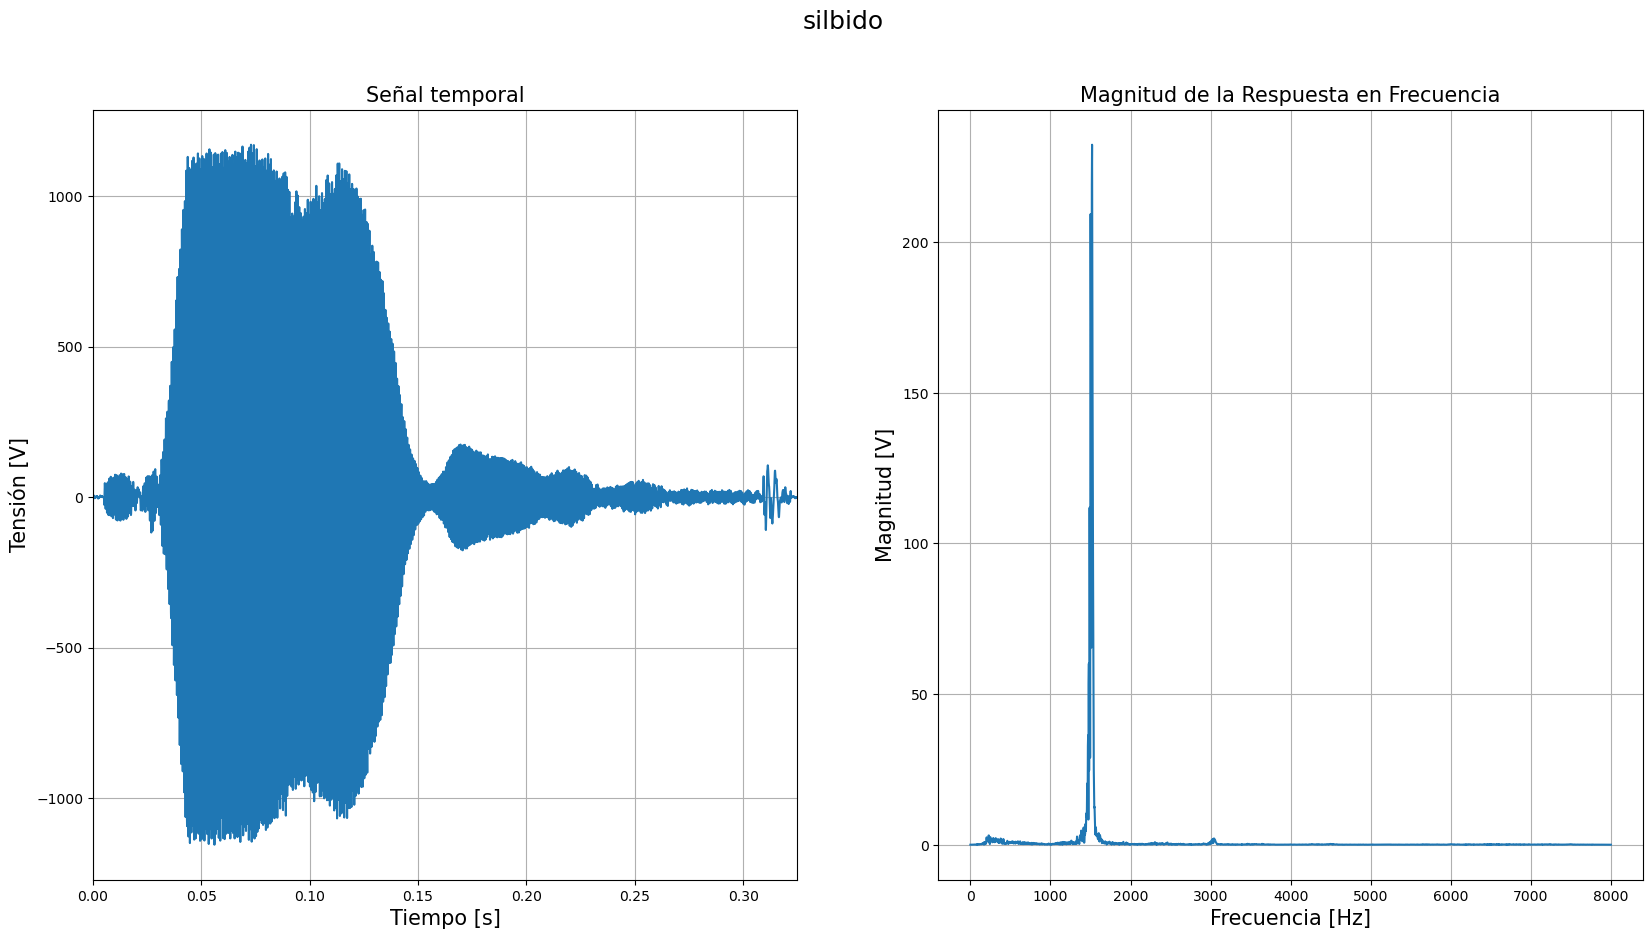

In [14]:
# Se crea una gráfica que contendrá dos sub-gráficos ordenados en una fila y dos columnas
fig1, ax1 = plt.subplots(1, 2, figsize=(20, 10))
fig1.suptitle(filename, fontsize=18)

# Se grafica la señal temporal
ax1[0].plot(t, senial)
ax1[0].set_xlabel('Tiempo [s]', fontsize=15)
ax1[0].set_ylabel('Tensión [V]', fontsize=15)
ax1[0].set_title('Señal temporal', fontsize=15)
ax1[0].set_xlim([0, ts*N])
ax1[0].grid()

# se grafica la magnitud de la respuesta en frecuencia
#ax1[1].plot(freq, senial_fft_mod)
ax1[1].plot(f, senial_fft_mod)
ax1[1].set_xlabel('Frecuencia [Hz]', fontsize=15)
ax1[1].set_ylabel('Magnitud [V]', fontsize=15)
ax1[1].set_title('Magnitud de la Respuesta en Frecuencia', fontsize=15)
#ax1[1].set_xlim([0, 2500])
ax1[1].grid()

plt.show()

## Análisis de armónicos

In [15]:
# Se calcula el espectro en potencia
senial_fft_pot = np.power(senial_fft_mod , 2)

# Se detecta la posición de los picos en la FFT
armonicos, _ = signal.find_peaks(senial_fft_pot,
                                 distance=10*N/fs,
                                 prominence=np.max(senial_fft_pot)/50)

print(f"La frecuencia fundamental del tono es de:")
print(f"  f0: {f[armonicos[0]]:.2f}Hz")

print("La frecuencia fundamental de los primeros 5 armónicos es de:")
for i in range(1, len(armonicos)):
    print(f"  f{i}: {f[armonicos[i]]:.2f}Hz")
    if i == 5:
        break

La frecuencia fundamental del tono es de:
  f0: 1470.49Hz
La frecuencia fundamental de los primeros 5 armónicos es de:
  f1: 1488.94Hz
  f2: 1501.25Hz
  f3: 1519.71Hz


### Graficación de armónicos


In [16]:
# Función para calcular la frecuencia de una nota, según la octava

def frecuencia(nota, octava):
    return 440 * np.exp(((octava-4) + ((nota-9)/12)) * np.log(2)) 

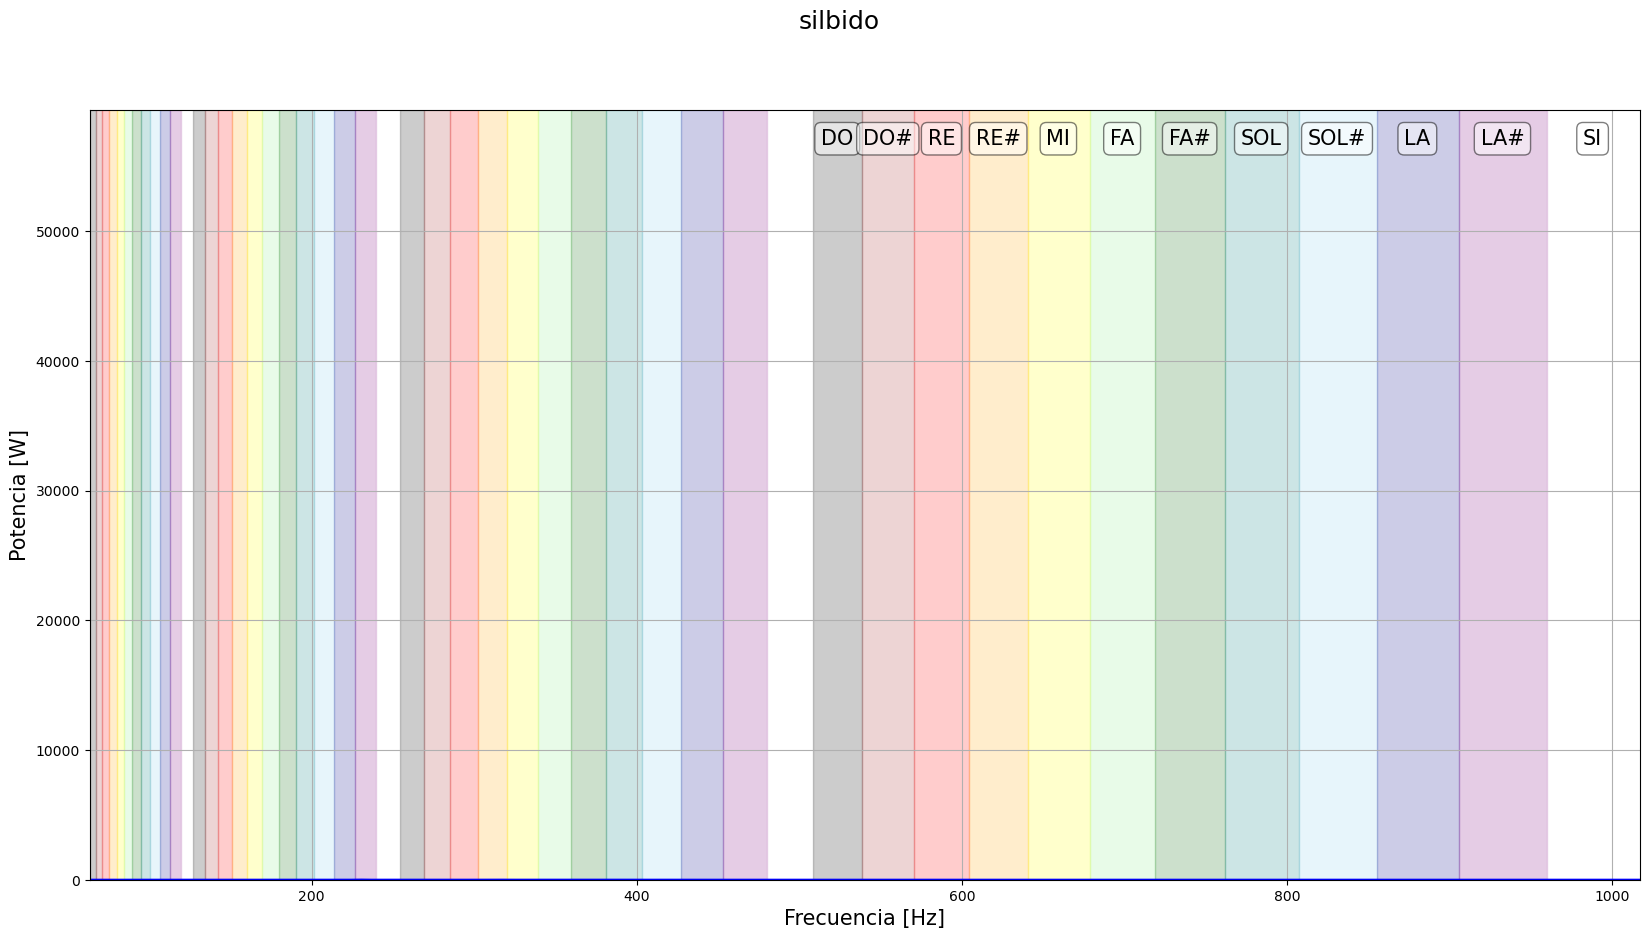

In [17]:
# Se crea una gráfica 
fig2, ax2 = plt.subplots(1, 1, figsize=(20, 10))
fig2.suptitle(filename, fontsize=18)

octava_inicial = 2
octava_final = 5

# Se grafica el espectro en potencia de la señal indicando la ubicación de los armónicos
ax2.plot(f, senial_fft_pot, label='FFT', zorder=2, color='blue')
ax2.plot(f[armonicos[0]-10 : armonicos[0]+10], 
         senial_fft_pot[armonicos[0]-10 : armonicos[0]+10], 
          label='Frec. fundamental',  color='red')
ax2.set_xlabel('Frecuencia [Hz]', fontsize=15)
ax2.set_ylabel('Potencia [W]', fontsize=15)
ax2.set_xlim([frecuencia(0-0.5, octava_inicial), frecuencia(0-0.5, octava_final+1)])
ax2.set_ylim(0, np.max(senial_fft_pot)*1.1)
# ax2.set_xscale("log")
ax2.grid()

# Se pinta el rango correspondiente a cada nota
notas = ['DO', 'DO#', 'RE', 'RE#', 'MI', 'FA', 'FA#', 'SOL', 'SOL#', 'LA', 'LA#', 'SI']
colores = ['black', 'brown', 'red', 'orange', 'yellow', 'lightgreen', 'darkgreen', 'teal', 'skyblue', 'darkblue', 'purple', 'white']
for octava in range(octava_inicial, octava_final+1):
    for nota in range(12):
        ax2.add_patch(plt.Rectangle((frecuencia(nota-0.5, octava), 0), 
                                    frecuencia(nota+0.5, octava)-(frecuencia(nota-0.5 ,octava)), 
                                    np.max(senial_fft_pot)*1.1, color=colores[nota], alpha=0.2))
for nota in range(12):
    ax2.text(frecuencia(nota, octava_final), np.max(senial_fft_pot)*1.05, 
                    f'{notas[nota]}', fontsize=15,
                    horizontalalignment='center',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))           
plt.show()


### Notas

![notas](frecuencia_notas.jpg)


### Acordes

![acordes](acordes.png)


### Perfil de Clase de Tonos (Pitch Class Profile)

El Perfil de Clase de Tonos (PCP), también conocido como Croma, es un vector de características que representa la intensidad de cada uno de los 12 semitonos de la escala musical, colapsando todas las octavas en una sola. 

La idea fundamental consiste en mapear todas las frecuencias del espectro a las 12 clases de notas (C, C#, D, D#, E, F, F#, G, G#, A, A#, B). Para obtener la clase de tono de un componente de frecuencia $f$, utilizamos la asignación estándar de notas MIDI:

$$ n = \text{round}\left(12 \cdot \log_2\left(\frac{f}{440}\right) + 69\right) \mod 12 $$

donde 440 Hz es la frecuencia base para la nota A4. Gracias a la operación aritmética $\text{mod } 12$, agrupamos todas las apariciones de cada nota musical sin importar su altura (octava).

In [9]:
def calcular_pcp(senial, fs, f_min=50.0, f_max=4000.0):
    N = len(senial)
    freq = fft.fftfreq(N, d=1/fs)
    espectro = fft.fft(senial)
    magnitud2 = np.abs(espectro)**2
    
    # Tomar la porción positiva del espectro
    f_pos = freq[freq > 0]
    mag_pos = magnitud2[freq > 0]
    
    # Filtrar solo el rango de frecuencias analizado
    mask = (f_pos >= f_min) & (f_pos <= f_max)
    f_val = f_pos[mask]
    mag_val = mag_pos[mask]
    
    # Calcular el índice del semitono en el rango 0..11 donde 0=C, 1=C#, ..., 9=A, etc.
    # La nota MIDI 69 es A4, por lo que su residuo es 9 (A). Así, el índice 0 corresponde a C.
    semitonos = (np.round(12 * np.log2(f_val / 440.0) + 69) % 12).astype(int)
    
    pcp = np.zeros(12)
    for m, s in zip(mag_val, semitonos):
        pcp[s] += m
        
    # Normalizar el PCP para facilitar la visualización comparativa
    if np.max(pcp) > 0:
        pcp = pcp / np.max(pcp)
        
    return pcp

Como ejemplo, calculemos y visualicemos el PCP de algunos de los distintos acordes cuyas grabaciones se encuentran anexadas en esta misma carpeta.

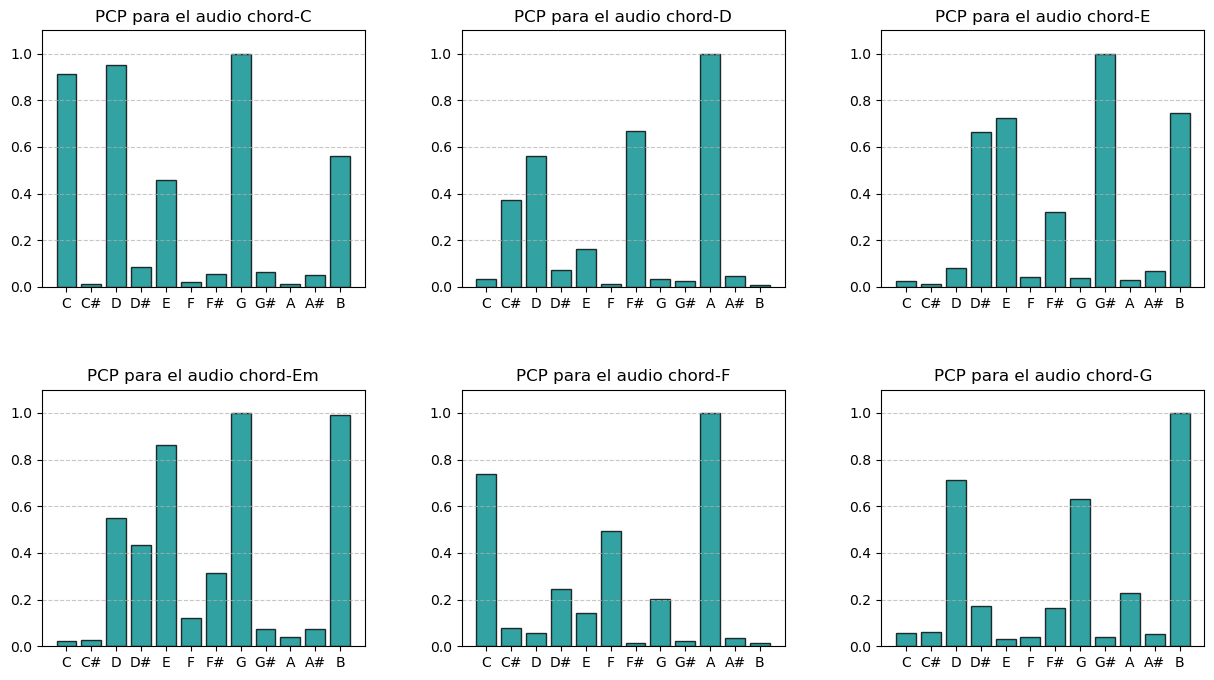

In [10]:
acordes = ['chord-C', 'chord-D', 'chord-E', 'chord-Em', 'chord-F', 'chord-G']
notas_label = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

for i, acorde in enumerate(acordes):
    fs_acorde, data_acorde = wavfile.read(f'{acorde}.wav')
    if len(data_acorde.shape) > 1:
        senial_acorde = data_acorde[:, 0]
    else:
        senial_acorde = data_acorde
        
    senial_acorde = senial_acorde * 3300.0 / (2 ** 16 - 1)  # Simular adquisición CAD a mV
    
    pcp = calcular_pcp(senial_acorde, fs_acorde)
    
    ax = axs[i//3, i%3]
    ax.bar(notas_label, pcp, color='darkcyan', edgecolor='black', alpha=0.8)
    ax.set_title(f'PCP para el audio {acorde}')
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()